Transfer Learning -> Chagned rruntime to GPU

In [1]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

In [2]:
# Load the Pre-trained model

print("**** Loading Pretrained Model ****")
model = VGG16(weights='imagenet')
print("Model Loaded")

**** Loading Pretrained Model ****
553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step
Model Loaded


In [7]:
#Function to load and classify image
def classify_image(img_path):
  if img_path.startswith('http'):
    response = requests.get(img_path)
    img = Image.open(BytesIO(response.content))
  else:
    img = image.load_img(img_path, target_size=(224, 224))

  plt.figure(figsize=(8, 6)) # How much size. Width and height 8 inches and 6 inches
  plt.imshow(img)
  plt.axis('off')
  plt.title("Input Image")
  plt.show()

  # Convert the image to array to give it to model
  img_array = image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array = preprocess_input(img_array)
  print("")

  # Make Predictions
  print("\n**** Making Predictions ****")
  predictions = model.predict(img_array)
  print("\n**** Predictions Complete ****")

  # Decode Predictions (the results is an matrix of pixels which is difficult to understand)
  decoded = decode_predictions(predictions, top=3)[0] # Taking top 3 predictions.

  # print(results)
  for i , (imagenet_id, label, score) in enumerate(decoded):
    print(f"{i+1}. {label} ({score*100:.2f}%)")
  return predictions

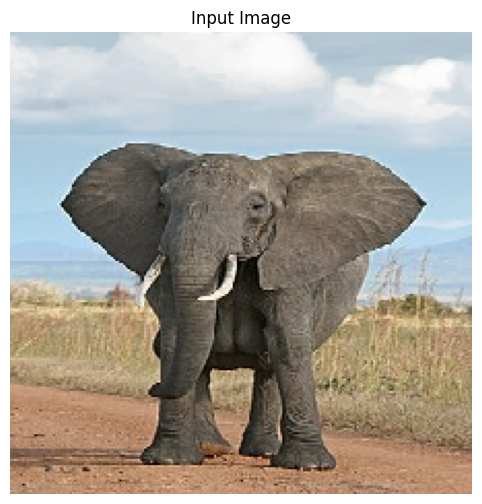



**** Making Predictions ****
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

**** Predictions Complete ****
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
1. African_elephant (92.40%)
2. tusker (7.44%)
3. Indian_elephant (0.15%)


array([[5.38851568e-11, 5.50979347e-14, 1.44412921e-12, 1.05561285e-12,
        3.08368652e-12, 1.38718148e-10, 4.21628314e-12, 8.80296758e-13,
        1.42412568e-12, 8.50787496e-11, 5.68633885e-15, 3.58777957e-15,
        1.82296425e-13, 3.96494666e-14, 4.39582696e-13, 1.60852099e-13,
        1.37488599e-13, 5.13083879e-13, 5.55183205e-14, 2.25438497e-14,
        5.08969711e-13, 5.65621369e-11, 2.92052979e-11, 1.07341816e-10,
        9.47363629e-12, 2.18895828e-14, 9.68331030e-15, 3.70282757e-14,
        8.31826334e-14, 5.11263666e-14, 1.54529235e-13, 3.46528023e-14,
        2.63557405e-13, 1.76473822e-10, 3.24508254e-10, 8.77123305e-11,
        4.27847119e-10, 9.50703231e-12, 9.60574719e-13, 9.18614421e-11,
        1.99233669e-13, 3.14749339e-13, 3.23551819e-12, 2.58924909e-10,
        2.03932696e-13, 2.93493935e-13, 2.23234571e-13, 2.03565238e-11,
        5.58807400e-09, 3.16702012e-11, 2.46950915e-11, 1.76075155e-05,
        4.49624197e-14, 1.91079276e-13, 2.39911335e-13, 8.936422

In [8]:
classify_image("/content/African_Bush_Elephant.jpg")

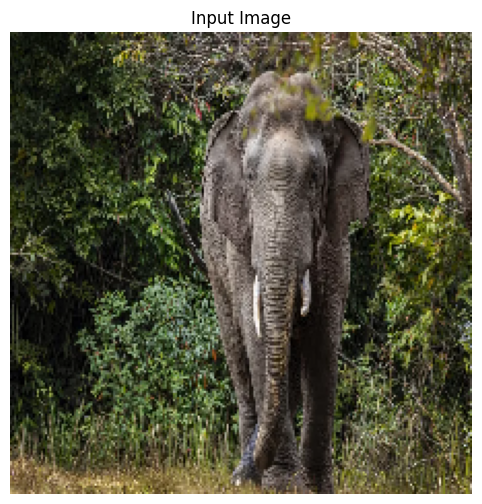



**** Making Predictions ****
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

**** Predictions Complete ****
1. tusker (69.13%)
2. Indian_elephant (21.61%)
3. African_elephant (9.26%)


array([[1.35877185e-08, 1.51542685e-11, 5.16922720e-11, 1.05951817e-10,
        3.91094018e-10, 4.09988848e-10, 9.01662564e-11, 4.44485615e-10,
        2.31441699e-10, 1.74928255e-06, 1.91589217e-10, 3.98549110e-10,
        7.87794052e-10, 3.12854603e-10, 2.51221349e-10, 1.10077991e-09,
        1.96483563e-09, 1.03091247e-09, 1.23994148e-09, 2.78071899e-10,
        2.61399347e-10, 3.96032760e-07, 2.14634639e-08, 1.26582518e-06,
        8.86541045e-08, 5.58049273e-10, 7.98267119e-10, 2.67404709e-11,
        1.29227670e-10, 5.46432677e-10, 9.91503990e-10, 8.21750099e-11,
        7.80968956e-10, 1.89348937e-09, 3.38053519e-09, 4.28875602e-09,
        5.34840838e-09, 8.87839802e-10, 1.95538807e-09, 1.64443009e-07,
        1.78250426e-09, 4.95558217e-09, 6.79652885e-08, 1.46870229e-06,
        2.61348587e-09, 5.95701755e-09, 2.20446461e-09, 5.79342192e-08,
        2.67428345e-06, 3.71530113e-08, 1.19366952e-08, 2.63256652e-06,
        1.28711652e-09, 1.66992775e-09, 3.33500028e-09, 1.523026

In [9]:
# Classify Indian Elephant
classify_image("/content/Indian_Elephant.jpg")

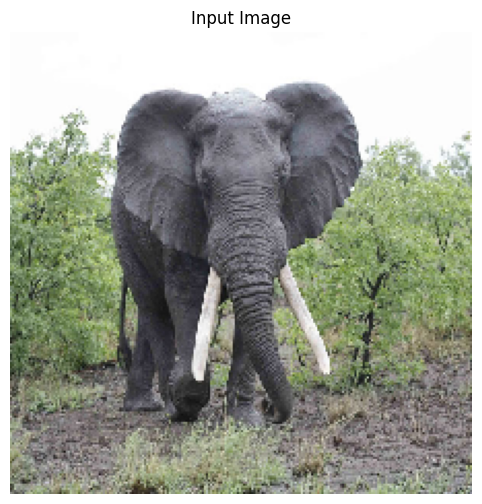



**** Making Predictions ****
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

**** Predictions Complete ****
1. tusker (82.14%)
2. African_elephant (13.55%)
3. Indian_elephant (4.30%)


array([[2.63406824e-10, 1.66860666e-13, 5.95681273e-13, 1.64103117e-12,
        4.84018858e-12, 4.55101408e-12, 5.14813669e-13, 2.48348425e-11,
        2.45006047e-11, 3.55043035e-08, 9.05459586e-14, 1.69329665e-13,
        5.84584410e-13, 2.03733094e-13, 3.44764603e-12, 1.37522914e-12,
        1.85586117e-12, 1.78054804e-12, 2.99081658e-12, 8.05803015e-13,
        1.60142158e-12, 8.64384328e-11, 1.75473386e-11, 4.71529304e-09,
        6.75808853e-11, 2.84937005e-12, 8.22097381e-13, 3.15859291e-13,
        2.26952441e-12, 3.09388192e-12, 6.11751014e-12, 1.72696818e-12,
        6.93556410e-12, 5.31341603e-11, 8.46411830e-11, 3.89041924e-11,
        5.64021156e-11, 5.09357010e-12, 2.98801695e-12, 1.91241301e-10,
        1.09359830e-12, 9.14970356e-13, 2.46669230e-11, 2.93122721e-10,
        6.16594839e-12, 1.13599659e-11, 3.07194916e-12, 1.85401985e-10,
        1.92890361e-08, 1.80174459e-10, 1.21772992e-09, 4.43036288e-06,
        2.14938614e-12, 9.27688221e-12, 6.56989307e-12, 8.186990

In [12]:
# Classify Tusker
classify_image("/content/Tusker Elephant.jpg")

Another way of using Keras pretrained model is Tensorflow Hub.

Read the model description to decide whether to use the model or not. For example: https://keras.io/api/applications/vgg/#vgg19-function

In [13]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np

model = ResNet50(weights='imagenet')

img_path = '/content/Indian_Elephant.jpg'
img = keras.utils.load_img(img_path, target_size=(224, 224))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

preds = model.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
print('Predicted:', decode_predictions(preds, top=3)[0])

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted: [('n01871265', 'tusker', np.float32(0.8936533)), ('n02504013', 'Indian_elephant', np.float32(0.08977958)), ('n02504458', 'African_elephant', np.float32(0.016560486))]


Above model predicted indian elephant as tusker 89%. so it is not a good model.

Sometimes the quality of image is not good then we can use Python OpenCV library (open source)

In [14]:
#Function to load and classify image
def classify_image(img_path):
    if img_path.startswith('http'):
        response = requests.get(img_path)
        img = Image.open(BytesIO(response.content))
    else:
        img = image.load_img(img_path,target_size=(224,224))
    #plt.figure(figsize=(8,6))
    #plt.imshow(img)
    #plt.axis('off')
    #plt.title("Input Image")
    #plt.show()
    #Preprocessing Image
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array,axis=0)
    img_array = preprocess_input(img_array)
    #print("")
    #Make Predictions
    #print("\nClassifying ...")
    predictions = model.predict(img_array)
    #print("\nPrediction Complete")
    #decoded predictions
    decoded = decode_predictions(predictions,top=1)[0]
    #print( results)
    results = {label:float(score) for (_,label,score) in decoded}
    return results

In [15]:
def test_funct(img):
  results=classify_image(img)
  return results

In [16]:
test_funct('/content/African_Bush_Elephant.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


{'African_elephant': 0.9408273696899414}

In [17]:
import gradio as gr

In [18]:
interface = gr.Interface(fn=test_funct,inputs= gr.Image(),outputs=gr.Label(num_top_classes=3))

In [ ]:
interface.launch(share = True,debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://e7079d9012eb4260b9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2116, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1623, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^